In [2]:
import sys
from pathlib import Path
import py_dss_interface
import networkx as nx
import pandas as pd

from unit_converter import UnitConverter
from fault import FaultSimulator
from topologia import FeederTopology
from locator import FaultLocator

In [3]:
BASE_DIR = Path("..").resolve()
BASE_DIR

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe')

In [4]:
DSS_FILE = BASE_DIR / "data" / "123Bus" / "run_ieee123_cosim_1h.dss"
DSS_FILE

WindowsPath('D:/UFC/LOCALIZACAO-DE-FALTAS/refatorando-codigo/tcc-luis-felipe/data/123Bus/run_ieee123_cosim_1h.dss')

In [5]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='150', target_kv=2.40)
simulador.topology.print_circuits_info()


🗺️  RESUMO DA TOPOLOGIA DOS CIRCUITOS MAPEADOS

C_1: L = 0.57 | Q = 2 | seçoes: [L115-L1]
C_2: L = 0.85 | Q = 3 | seçoes: [L115-L2-L4]
C_3: L = 1.23 | Q = 4 | seçoes: [L115-L2-L5-L6]
C_4: L = 1.12 | Q = 4 | seçoes: [L115-L3-L7-L8]
C_5: L = 1.80 | Q = 6 | seçoes: [L115-L3-L7-L9-L11-L14]
C_6: L = 1.80 | Q = 6 | seçoes: [L115-L3-L7-L9-L11-L15]
C_7: L = 1.82 | Q = 7 | seçoes: [L115-L3-L7-L10-L12-L34-L16]
C_8: L = 1.80 | Q = 7 | seçoes: [L115-L3-L7-L10-L12-L34-L17]
C_9: L = 2.60 | Q = 7 | seçoes: [L115-L3-L7-L10-L13-L18-L20]
C_10: L = 2.85 | Q = 7 | seçoes: [L115-L3-L7-L10-L13-L19-L21]
C_11: L = 1.93 | Q = 7 | seçoes: [L115-L3-L7-L10-L116-L52-L53]
C_12: L = 3.12 | Q = 8 | seçoes: [L115-L3-L7-L10-L13-L19-L22-L23]
C_13: L = 3.35 | Q = 8 | seçoes: [L115-L3-L7-L10-L13-L114-L35-L37]
C_14: L = 2.98 | Q = 8 | seçoes: [L115-L3-L7-L10-L13-L114-L36-L40]
C_15: L = 3.62 | Q = 9 | seçoes: [L115-L3-L7-L10-L13-L114-L35-L38-L39]
C_16: L = 3.40 | Q = 9 | seçoes: [L115-L3-L7-L10-L13-L114-L36-L41-L42]
C_17: 

In [5]:
simulador = FaultSimulator(str(DSS_FILE), origin_bus='150', target_kv=2.40)
# 3. (Opcional) Imprime o resumo da topologia descoberta automaticamente
# Isso chamará aquele método de print bonito que configuramos na FeederTopology

# 4. Configura os parâmetros da varredura
# Varrendo a linha de 10% em 10%
passo_distancia = 0.30 
passo_distancia_m = 10.0

# Lista de resistências de falta (em Ohms)
resistencias_falta = [0.0001, 10.0, 20.0, 30.0, 40.0]  
resistencias_falta = [0.0001]  

# 5. Executa o laço principal da simulação
print("\nIniciando a varredura linear de curtos-circuitos...")

simulador.run_simulation(step_abs_m=passo_distancia_m, r_list=resistencias_falta)

localizador = FaultLocator(str(DSS_FILE), simulador.topology,
                           pd.DataFrame(simulador.results))

localizador.run_minimum_reactance()

localizador.apply_mi_filter()



Iniciando a varredura linear de curtos-circuitos...


Aplicando Filtro MI: 100%|██████████| 6470/6470 [00:00<00:00, 7795.29it/s]


In [6]:
localizador.df

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_39_line,circuito_40_d,circuito_40_line,circuito_41_d,circuito_41_line,circuito_42_d,circuito_42_line,linha_estimada,dist_estimada,erro_percentual
0,2361.706956,-16.805804,-1200.907451,-2079.993981,-1200.880945,2080.017167,127810.957468,-296395.217128,-43.309791,-140.774456,...,l115,10.000004,l115,10.000004,l115,10.000004,l115,l115,10.000003,1.684227e-07
1,2401.787611,-0.023150,-1196.051671,-2035.932534,-1200.871975,2080.013100,171.189804,79.651746,-327695.051763,32655.336590,...,l115,10.000005,l115,10.000005,l115,10.000005,l115,l115,10.000004,2.170299e-07
2,2401.774898,-0.027173,-1200.904215,-2080.003209,-1165.804132,2053.731443,202.011428,-14.485385,24.997479,-116.055533,...,l115,10.000003,l115,10.000004,l115,10.000003,l115,l115,10.000003,1.540385e-07
3,2365.478354,-57.544247,-1164.603750,-2022.468168,-1200.876539,2080.012214,430138.396017,-265354.976705,-430045.134308,265252.227829,...,l115,10.000005,l115,10.000005,l115,10.000005,l115,l115,10.000005,2.725692e-07
4,2401.779995,-0.023065,-1227.185130,-2023.788552,-1174.597128,2023.804771,171.120744,23.070827,-415588.662328,-199507.911592,...,l115,10.000004,l115,10.000004,l115,10.000003,l115,l115,10.000003,1.803610e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6465,2401.177239,0.051753,-1200.903767,-2079.997557,-1200.272331,2079.938688,-339.856469,-4459.793421,-17.015687,-113.141756,...,l117,1004.006911,l60,1016.497819,l45,586.740000,l53,l117,1014.809241,-4.854462e-01
6466,2401.292970,-0.440874,-1200.655212,-2079.372049,-1200.876631,2080.016281,3310.805353,-3563.546838,-4681.794334,1686.675028,...,l117,1037.131573,l60,1060.614221,l48,586.740000,l53,l53,586.740000,-2.304652e+01
6467,2401.782304,-0.024298,-1201.031744,-2079.354656,-1200.458089,2079.482023,180.105603,40.310357,-4783.018215,-1111.517983,...,l117,1011.329615,l60,973.280697,l45,586.740000,l53,l53,586.740000,-2.304652e+01
6468,2401.154025,-0.098866,-1200.906772,-2080.000255,-1200.293481,2079.784811,780.673813,-4621.042014,3.243838,-135.263313,...,l117,1003.724047,l60,1015.556299,l45,586.740000,l53,l53,586.740000,-2.304652e+01


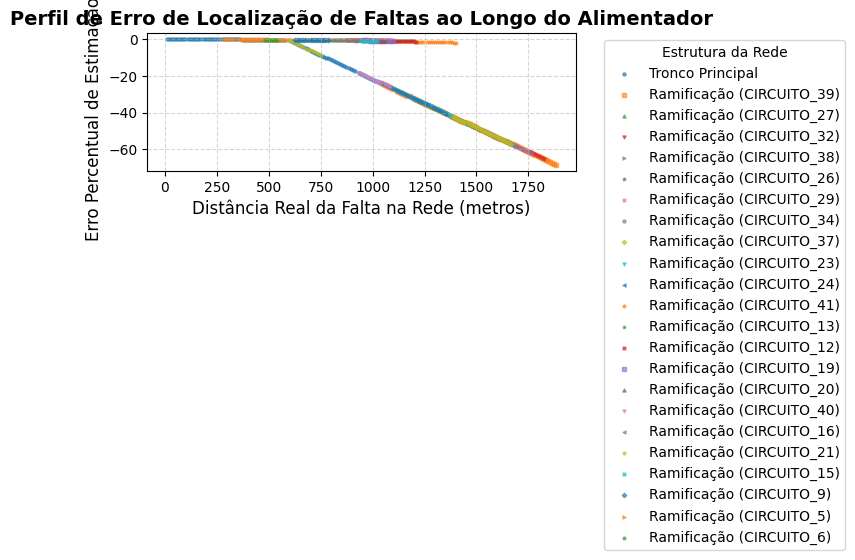

In [7]:

import matplotlib.pyplot as plt

"""
Gera um gráfico do erro percentual em função da distância.
Plota primeiro o tronco principal e depois as ramificações exclusivas de cada circuito.
"""
plt.figure(figsize=(8, 4))

# 1. Ordena os circuitos do maior para o menor (em quantidade de seções)
# O maior será naturalmente o "tronco principal"
circuitos_ordenados = sorted(localizador.topology.main_circuits.items(), key=lambda item: len(item[1]), reverse=True)

# Conjunto para rastrear quais linhas já foram plotadas
linhas_plotadas = set()

# Paleta de marcadores para diferenciar visualmente os ramais
marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']

for idx, (nome_circuito, linhas) in enumerate(circuitos_ordenados):
    # 2. Filtra as linhas: pega apenas as que AINDA NÃO estão no tronco/ramais anteriores
    linhas_do_ramal = [linha for linha in linhas if linha not in linhas_plotadas]
    
    if not linhas_do_ramal:
        continue # Se todas as linhas já foram plotadas (circuito 100% redundante), pula.
        
    # 3. Filtra o DataFrame para pegar as distâncias e erros dessas linhas específicas
    df_ramal = localizador.df[localizador.df['linha_faltosa'].isin(linhas_do_ramal)]
    # Exemplo se quisesse filtrar:
    df_ramal = localizador.df[(localizador.df['linha_faltosa'].isin(linhas_do_ramal)) & (localizador.df['tipo'] == 'at') & (localizador.df['r'] == 0.0001)]
    
    if df_ramal.empty:
        continue
        
    # Define o nome para a legenda
    label_nome = "Tronco Principal" if idx == 0 else f"Ramificação ({nome_circuito.upper()})"
    
    # 4. Plota os dados em gráfico de dispersão (Scatter)
    # Scatter é ideal porque para uma mesma distância temos vários erros (tipos de falta e resistências diferentes)
    plt.scatter(df_ramal['distancia'], df_ramal['erro_percentual'], label=label_nome, marker=marcadores[idx % len(marcadores)], alpha=0.6, s=5)
    
    # 5. Adiciona as linhas desenhadas ao conjunto de bloqueio
    linhas_plotadas.update(linhas_do_ramal)

# Configurações de estética do gráfico
plt.title('Perfil de Erro de Localização de Faltas ao Longo do Alimentador', fontsize=14, fontweight='bold')
plt.xlabel('Distância Real da Falta na Rede (metros)', fontsize=12)
plt.ylabel('Erro Percentual de Estimação (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Coloca a legenda fora do gráfico para não sobrepor os dados
plt.legend(title='Estrutura da Rede', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ajusta as margens automaticamente

# # Salva o gráfico ou exibe na tela
# if save_path:
#     Path(save_path).parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f"📊 Gráfico gerado e salvo com sucesso em: {save_path}")
# else:
plt.show()

In [8]:
localizador.export_results(
    output_dir= BASE_DIR / "result",
    filename= "ieee_123_node_result_10m.csv"
)

✅ Análise concluída. Resultados salvos em: C:\Users\GREI-Luis-Felipe\Documents\GitHub\tcc-luis-felipe\result\ieee_123_node_result_10m.csv


In [15]:
results_df = pd.read_csv(BASE_DIR / "result" / "ieee_123_node_result_10m.csv", sep=";", decimal=",")
results_df.head()

,va_r,va_i,vb_r,vb_i,vc_r,vc_i,ia_r,ia_i,ib_r,ib_i,...,circuito_39_line,circuito_40_d,circuito_40_line,circuito_41_d,circuito_41_line,circuito_42_d,circuito_42_line,linha_estimada,dist_estimada,erro_percentual
0,2361.706956,-16.805804,-1200.907451,-2079.993981,-1200.880945,2080.017167,127810.957468,-296395.217128,-43.309791,-140.774456,...,l115,10.000004,l115,10.000004,l115,10.000004,l115,l115,10.000003,1.684227e-07
1,2401.787611,-0.023150,-1196.051671,-2035.932534,-1200.871975,2080.013100,171.189804,79.651746,-327695.051763,32655.336590,...,l115,10.000005,l115,10.000005,l115,10.000005,l115,l115,10.000004,2.170299e-07
2,2401.774898,-0.027173,-1200.904215,-2080.003209,-1165.804132,2053.731443,202.011428,-14.485385,24.997479,-116.055533,...,l115,10.000003,l115,10.000004,l115,10.000003,l115,l115,10.000003,1.540385e-07
3,2365.478354,-57.544247,-1164.603750,-2022.468168,-1200.876539,2080.012214,430138.396017,-265354.976705,-430045.134308,265252.227829,...,l115,10.000005,l115,10.000005,l115,10.000005,l115,l115,10.000005,2.725692e-07
4,2401.779995,-0.023065,-1227.185130,-2023.788552,-1174.597128,2023.804771,171.120744,23.070827,-415588.662328,-199507.911592,...,l115,10.000004,l115,10.000004,l115,10.000003,l115,l115,10.000003,1.803610e-07


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\luisx\AppData\Local\Temp\ipykernel_15072\1825874806.py:7: SyntaxWarning: invalid escape sequence '\s'
  df_coords = pd.read_csv(BASE_DIR / "data" / "123Bus" / "BusCoords.dat", sep='\s+',header=None, names=['Bus', 'X', 'Y'])


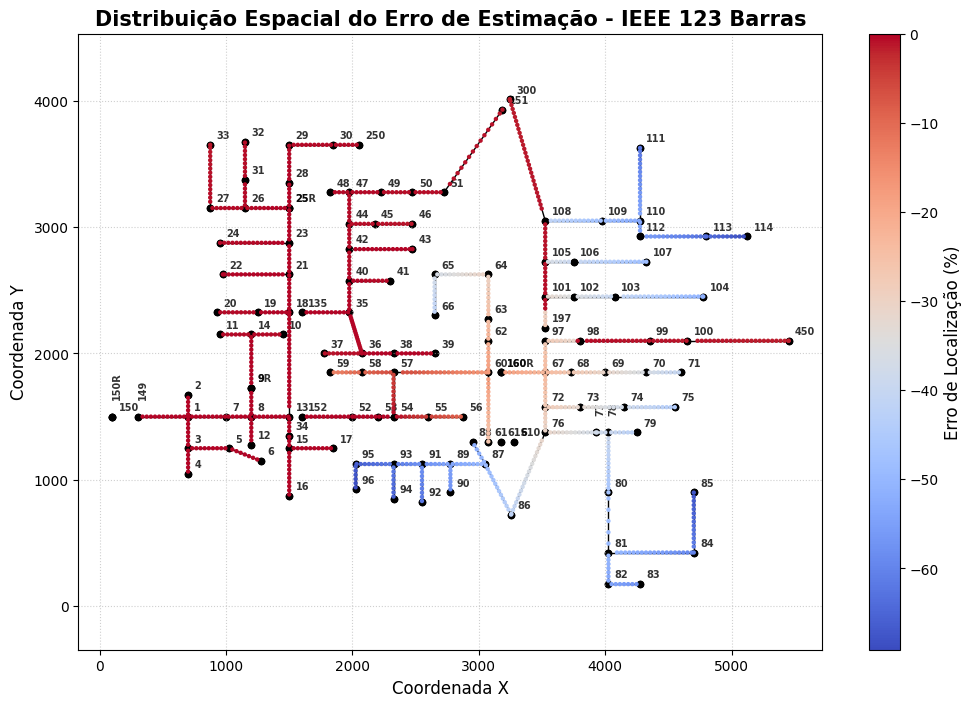

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS ---
# Coordenadas das barras (enviadas por você)
df_coords = pd.read_csv(BASE_DIR / "data" / "123Bus" / "BusCoords.dat", sep='\s+',header=None, names=['Bus', 'X', 'Y'])
coords = {str(row['Bus']).lower(): (row['X'], row['Y']) for _, row in df_coords.iterrows()}

# Resultados da simulação (gerados anteriormente)
# df_res = pd.read_csv('result/localizacao_filtrada.csv', sep=';', decimal=',')

# --- 2. CONFIGURAÇÃO DO PLOT ---
plt.figure(figsize=(12, 8))
plt.rcParams["font.family"] = "DejaVu Sans"

# --- 3. DESENHAR A ESTRUTURA DA REDE (LINHAS CINZAS) ---
# Usamos a topologia mapeada para saber quem conecta com quem
for line_name, info in simulador.topology.line_data.items():
    b1, b2 = info['bus1'], info['bus2']
    if b1 in coords and b2 in coords:
        x_values = [coords[b1][0], coords[b2][0]]
        y_values = [coords[b1][1], coords[b2][1]]
        # plt.plot(x_values, y_values, color='lightgray', linewidth=1, zorder=1)
        plt.plot(x_values, y_values, color='black', linewidth=1, zorder=1)

bus_x = [coord[0] for coord in coords.values()]
bus_y = [coord[1] for coord in coords.values()]
plt.scatter(bus_x, bus_y, color='black', s=20, zorder=1, label='Barras (Nós)')

# --- 3.2 Desenhar as Barras/Nós ---
barras_rotacionadas = ['77', '78', '150r', '149']

for bus_name, (bx, by) in coords.items():
    # Desenha o ponto da barra
    plt.scatter(bx, by, color='black', s=20, zorder=1)
    
    rotacao = 0
    deslocamento_x = 50
    deslocamento_y = 50

    if bus_name in barras_rotacionadas:
        rotacao = 90
        # Dica: Quando você rotaciona o texto, às vezes ele fica em cima da linha.
        # Você pode ajustar o deslocamento X e Y especificamente para elas:
        deslocamento_x = 0
        deslocamento_y = 150

    # Adiciona o nome da barra com um pequeno deslocamento (ex: +50 unidades em X e Y)
    # ha='left' e va='bottom' ajudam a posicionar o texto para fora do ponto
    plt.text(bx + deslocamento_x, by + deslocamento_y, bus_name.upper(), 
             fontsize=7, 
             fontweight='bold',
             color='black',
             alpha=0.8,
             zorder=1,
             rotation=rotacao)

# Adiciona uma entrada manual na legenda para as barras, se desejar
plt.scatter([], [], color='black', s=40, label='Barras (Nós)')

# --- 4. PLOTAR OS ERROS (HEATMAP HÍBRIDO DE MÁXIMA COBERTURA) ---
# results_df = localizador.df.copy()

# 1. Filtramos apenas pela resistência desejada (Sem filtrar o tipo ainda)
resistencia_alvo = 0.0001
df_res_alvo = results_df[results_df['r'] == resistencia_alvo].copy()

x_faltas, y_faltas, erros = [], [], []

# 2. Ordem de prioridade: O que o algoritmo deve tentar plotar primeiro
prioridade_faltas = ['abc', 'ab', 'bc', 'ac', 'at', 'bt', 'ct']

# Iteramos por CADA LINHA única simulada com essa resistência
for line_name in df_res_alvo['linha_faltosa'].unique():
    
    # Pega todos os dados simulados apenas para esta linha específica
    df_linha_completo = df_res_alvo[df_res_alvo['linha_faltosa'] == line_name]
    tipos_simulados = df_linha_completo['tipo'].unique()
    
    # 3. Descobre qual é a "maior" falta possível para essa linha
    tipo_escolhido = None
    for tipo in prioridade_faltas:
        if tipo in tipos_simulados:
            tipo_escolhido = tipo
            break
            
    # Se encontrou um tipo válido, isola os pontos de distância apenas dele
    if tipo_escolhido:
        df_linha = df_linha_completo[df_linha_completo['tipo'] == tipo_escolhido]
        line_info = simulador.topology.line_data.get(line_name)
        
        if line_info:
            b1, b2 = line_info['bus1'], line_info['bus2']
            if b1 in coords and b2 in coords:
                length_m = UnitConverter.to_km(line_info['length'], simulador.units) * 1000.0
                
                # Correção geométrica relativa para garantir que os pontos cubram a linha
                dist_min_csv = df_linha['distancia'].min()
                base_csv = dist_min_csv - (0.1 * length_m)

                for _, row in df_linha.iterrows():
                    m = (row['distancia'] - base_csv) / length_m
                    m = np.clip(m, 0, 1)

                    xf = coords[b1][0] + m * (coords[b2][0] - coords[b1][0])
                    yf = coords[b1][1] + m * (coords[b2][1] - coords[b1][1])
                    
                    x_faltas.append(xf)
                    y_faltas.append(yf)
                    erros.append(row['erro_percentual']) # Mantém o sinal real de erro

# Plotagem do gradiente de erro com escala divergente (Coolwarm)
sc = plt.scatter(x_faltas, y_faltas, c=erros, cmap='coolwarm', s=10, edgecolors='none', zorder=2)

# --- 5. ESTÉTICA E BARRA DE CORES ---
# ... (mantenha o restante do seu código de estética original aqui)

# --- 5. ESTÉTICA E BARRA DE CORES ---
cbar = plt.colorbar(sc)
cbar.set_label('Erro de Localização (%)', fontsize=12)

plt.title('Distribuição Espacial do Erro de Estimação - IEEE 123 Barras', fontsize=15, fontweight='bold')
plt.xlabel('Coordenada X', fontsize=12)
plt.ylabel('Coordenada Y', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Mantém a proporção da rede

plt.show()